In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import anndata

In [2]:
var = pd.read_csv('C:/Users/mdhdu/AppData/Local/Programs/Python310/Scripts/cmd/data/Synapse_Data/Synapse_Data/filtered_gene_row_names.txt', sep='\t')
column_name_mapping = {'FO538757.2': 'gene_ids'}
var.rename(columns=column_name_mapping, inplace=True)

In [3]:
var['gene_ids_duplicate'] = var.loc[:, 'gene_ids']
column_name_mapping = {'gene_ids_duplicate': 'Feature_ids'}
var.rename(columns=column_name_mapping, inplace=True)

In [4]:
var

,gene_ids,Feature_ids
0,FO538757.2,FO538757.2
1,SAMD11,SAMD11
2,NOC2L,NOC2L
3,KLHL17,KLHL17
4,PLEKHN1,PLEKHN1
...,...,...
17921,C21orf58,C21orf58
17922,PCNT,PCNT
17923,DIP2A,DIP2A
17924,S100B,S100B


In [5]:
var.to_csv('C:/Users/mdhdu/AppData/Local/Programs/Python310/Scripts/cmd/data/filtered_gene_row_names.txt')

In [6]:
obs1 = pd.read_csv('C:/Users/mdhdu/AppData/Local/Programs/Python310/Scripts/cmd/data/Synapse_Data/Synapse_Data/filtered_column_metadata.txt', sep='\t')

In [7]:
obs2 = pd.read_csv('C:/Users/mdhdu/AppData/Local/Programs/Python310/Scripts/cmd/data/ROSMAP_Metadata/ROSMAP_Metadata/ROSMAP_clinical.csv')


In [8]:
# Initialize a new column 'Classification' with NA values
obs2['disease'] = None

# Iterate over rows and apply the classification logic
for i in range(len(obs2)):
    # Check if CERAD, braaksc, and cts_mmse30_lv are not NaN
    if pd.notna(obs2.loc[i, 'ceradsc']) and pd.notna(obs2.loc[i, 'braaksc']) and pd.notna(obs2.loc[i, 'cts_mmse30_lv']):
        
        # Check for conditions to classify as Control, AsymAD, AD, or Exclude
        if ((obs2.loc[i, 'ceradsc'] in [4, 3] and obs2.loc[i, 'braaksc'] in [0, 1, 2]) or 
            (obs2.loc[i, 'ceradsc'] == 4 and obs2.loc[i, 'braaksc'] == 3)) and obs2.loc[i, 'cts_mmse30_lv'] >= 24:
            obs2.loc[i, 'disease'] = 'Control'
        elif (obs2.loc[i, 'ceradsc'] in [3, 2, 1] and obs2.loc[i, 'braaksc'] in [3, 4, 5, 6] and 
              obs2.loc[i, 'cts_mmse30_lv'] >= 24):
            obs2.loc[i, 'disease'] = 'AsymAD'
        elif (obs2.loc[i, 'ceradsc'] in [2, 1] and obs2.loc[i, 'braaksc'] in [3, 4, 5, 6] and 
              obs2.loc[i, 'cts_mmse30_lv'] < 24):
            obs2.loc[i, 'disease'] = 'AD'
        else:
            obs2.loc[i, 'disease'] = 'Exclude'

# Set 'NA' for any remaining missing classifications
obs2['disease'].fillna('NA', inplace=True)

In [9]:
obs1.head(3)

,TAG,projid,tsne1,tsne2,pre.cluster,broad.cell.type,Subcluster
0,AAACGGGAGATCCCGC.1,11409232,18.076541,43.899396,15,Ex,Ex8
1,AAATGCCTCCAATGGT.1,11409232,8.130535,20.687424,3,Ex,Ex0
2,AACCATGTCAGTGCAT.1,11409232,17.088242,47.272289,15,Ex,Ex8


In [10]:
obs2.head(3)

,projid,Study,msex,educ,race,spanish,apoe_genotype,age_at_visit_max,age_first_ad_dx,age_death,cts_mmse30_first_ad_dx,cts_mmse30_lv,pmi,braaksc,ceradsc,cogdx,dcfdx_lv,individualID,disease
0,10101589,ROS,1.0,20.0,1.0,2.0,34.0,90+,90+,90+,18.0,5.0,9.916667,4.0,2.0,4.0,4.0,R6939144,AD
1,86767530,MAP,0.0,10.0,1.0,2.0,33.0,90+,90+,90+,18.0,10.0,6.500000,4.0,2.0,4.0,4.0,R3893503,AD
2,9650662,MAP,0.0,15.0,1.0,2.0,23.0,90+,90+,90+,0.0,0.0,3.850000,3.0,2.0,4.0,4.0,R8937093,AD


In [11]:
# Assuming 'disease' is the name of your column
disease_counts = obs2['disease'].value_counts()

# Display the result
print(disease_counts)


disease
NA         1989
AD          577
AsymAD      494
Exclude     267
Control     257
Name: count, dtype: int64


In [12]:
obs3=obs1.merge(obs2, on="projid", how="left" )

In [13]:
column_name_mapping = {'broad.cell.type': 'cell_type','msex': 'sex'}

In [14]:
obs3.rename(columns=column_name_mapping, inplace=True)

In [15]:
obs3 = obs3.replace(np.nan, ' ')

In [16]:
obs3.head(3)

,TAG,projid,tsne1,tsne2,pre.cluster,cell_type,Subcluster,Study,sex,educ,...,age_death,cts_mmse30_first_ad_dx,cts_mmse30_lv,pmi,braaksc,ceradsc,cogdx,dcfdx_lv,individualID,disease
0,AAACGGGAGATCCCGC.1,11409232,18.076541,43.899396,15,Ex,Ex8,ROS,1.0,22.0,...,80.098562628336751,,30.0,1.333333,3.0,4.0,2.0,2.0,R8744945,Control
1,AAATGCCTCCAATGGT.1,11409232,8.130535,20.687424,3,Ex,Ex0,ROS,1.0,22.0,...,80.098562628336751,,30.0,1.333333,3.0,4.0,2.0,2.0,R8744945,Control
2,AACCATGTCAGTGCAT.1,11409232,17.088242,47.272289,15,Ex,Ex8,ROS,1.0,22.0,...,80.098562628336751,,30.0,1.333333,3.0,4.0,2.0,2.0,R8744945,Control


In [17]:
obs3.to_csv('C:/Users/mdhdu/AppData/Local/Programs/Python310/Scripts/cmd/data/filtered_column_metadata.txt')

In [19]:
adata = sc.read('C:/Users/mdhdu/AppData/Local/Programs/Python310/Scripts/cmd/data/Synapse_Data/Synapse_Data/filtered_count_matrix.mtx',cache=True).transpose()

C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\anndata\__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [20]:
adata.var = var
adata.obs = obs3

In [21]:
adata.obs = adata.obs.astype(str)
adata.var = adata.var.astype(str)

In [22]:
adata.var.set_index('gene_ids', inplace=True)
adata.var_names_make_unique()

In [23]:
adata.write('C:/Users/mdhdu/AppData/Local/Programs/Python310/Scripts/cmd/data/ADP1.h5ad')

In [22]:
if 'cell_type' in adata.obs.columns:
    cell_type_counts = adata.obs['cell_type'].value_counts()
    print("Cell type counts:")
    print(cell_type_counts)
    
    # Get the total count of all cells
    total_cell_count = cell_type_counts.sum()
    print(f"Total number of cells: {total_cell_count}")
else:
    print("Cell type information not found in 'cell_type' column.")

Cell type counts:
cell_type
Ex     34976
Oli    18235
In      9196
Ast     3392
Opc     2627
Mic     1920
Per      167
End      121
Name: count, dtype: int64
Total number of cells: 70634


In [23]:
adata

AnnData object with n_obs × n_vars = 70634 × 17926
    obs: 'TAG', 'projid', 'tsne1', 'tsne2', 'pre.cluster', 'cell_type', 'Subcluster', 'Study', 'sex', 'educ', 'race', 'spanish', 'apoe_genotype', 'age_at_visit_max', 'age_first_ad_dx', 'age_death', 'cts_mmse30_first_ad_dx', 'cts_mmse30_lv', 'pmi', 'braaksc', 'ceradsc', 'cogdx', 'dcfdx_lv', 'individualID', 'disease'
    var: 'gene_ids'

In [24]:
sc.logging.print_header()
sc.settings.set_figure_params(facecolor="white")

scanpy==1.9.5 anndata==0.10.3 umap==0.5.4 numpy==1.26.3 scipy==1.11.3 pandas==2.1.4 scikit-learn==1.1.3 statsmodels==0.14.0 igraph==0.10.8 louvain==0.8.0 pynndescent==0.5.10


In [25]:
sc.pp.log1p(adata)

In [26]:
adata.raw = adata

C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\anndata\_core\anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [27]:
sc.pp.scale(adata, max_value=10)

In [28]:
sc.tl.pca(adata, svd_solver="arpack")

In [29]:
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=50)

In [30]:
sc.tl.tsne(adata)

C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\sklearn\manifold\_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


In [31]:
sc.tl.louvain(adata)

In [33]:
adata.write('C:/Users/mdhdu/AppData/Local/Programs/Python310/Scripts/cmd/data/ADP3.h5ad')

In [34]:
marker_genes  = ["FLT1","CLDN5","AQP4","GFAP", "C3","CD74","CSF1R","PDGFRA","VCAN","CSPG4","MBP","MOBP","PLP1","GAD1","GAD2","NRGN","SLC17A7","CAMK2A","SYT1","GRIN1","SNAP25"]

C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()


C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\scanpy\tools\_dendrogram.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()
C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


TypeError: close() argument must be a Figure, an int, a string, or None, not <class 'scanpy.plotting._dotplot.DotPlot'>

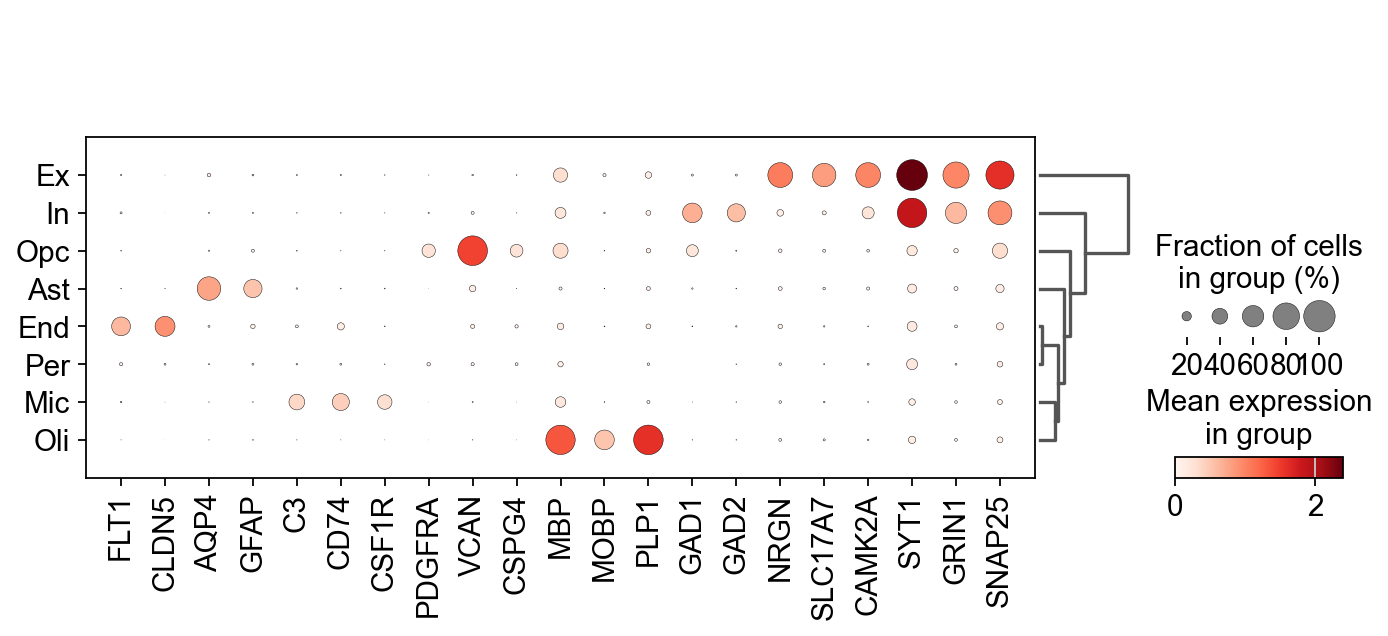

In [37]:
plt.rcParams['font.size'] = 16
fig1 = sc.pl.dotplot(adata, marker_genes, groupby="cell_type",gene_symbols="gene_ids", dendrogram=True, return_fig=True)
fig1.savefig('dotplot1.pdf', dpi=300)
plt.close(fig1)

In [38]:
risk_genes = ['MICU3', 'SLC7A2','RBM14','RBM4','RBM14-RBM4','SLC12A5','MRAS','GALNT8','KCNA6', 'STK24','PRDM4','TRIM23','VPS13C', 'BMPR1B','FNTB','CHURC1-FNTB','RAB15', 'LMO7']

In [39]:
bdata = adata[:, adata.var.gene_ids.isin(risk_genes)]

In [48]:
bdata.var

,gene_ids,mean,std
3732,MRAS,0.142330,0.330570
4400,BMPR1B,0.053371,0.221877
4880,TRIM23,0.164889,0.352847
8008,MICU3,0.274386,0.454348
8013,SLC7A2,0.019112,0.123318
9859,RBM14-RBM4,0.073476,0.226480
9860,RBM4,0.029319,0.143720
11054,GALNT8,0.095482,0.267235
11748,PRDM4,0.044554,0.177636
12178,LMO7,0.217953,0.421064


In [41]:
bdata.write('C:/Users/mdhdu/AppData/Local/Programs/Python310/Scripts/cmd/data/BDP3.h5ad')

In [44]:
# Set the font size for the plot
plt.rcParams['font.size'] = 16

# Create the t-SNE plot and return the figure
fig = sc.pl.tsne(adata, color="cell_type", legend_fontsize=14, return_fig=True)

# Save the plot to a PDF file with high resolution (300 dpi)
fig.savefig('tsne_plot1.pdf', dpi=300, bbox_inches='tight')

# Close the figure after saving
plt.close(fig)

C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_tools\scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_tools\scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


In [46]:
# Define the group order, excluding 'Exclude'
group_order = ["Control", "AsymAD", "AD"]

# Filter the data to remove 'Exclude' from the 'disease' column
adata_filtered = adata[adata.obs['disease'] != 'Exclude'].copy()

# Set the font size for the plot
plt.rcParams['font.size'] = 16

# Create the t-SNE plot using the filtered data and return the figure
fig = sc.pl.tsne(adata_filtered, color="disease", legend_fontsize=14, return_fig=True)

# Save the plot to a PDF file with high resolution (300 dpi)
fig.savefig('tsne_plot2.pdf', dpi=300, bbox_inches='tight')

# Close the figure after saving
plt.close(fig)

C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\anndata\_core\anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\anndata\_core\anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_tools\scatterplots.py:1216: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\Users\mdhdu\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_tools\scatterplots.py:391: UserWarning: No data for colormapping provided vi

<Figure size 800x800 with 0 Axes>

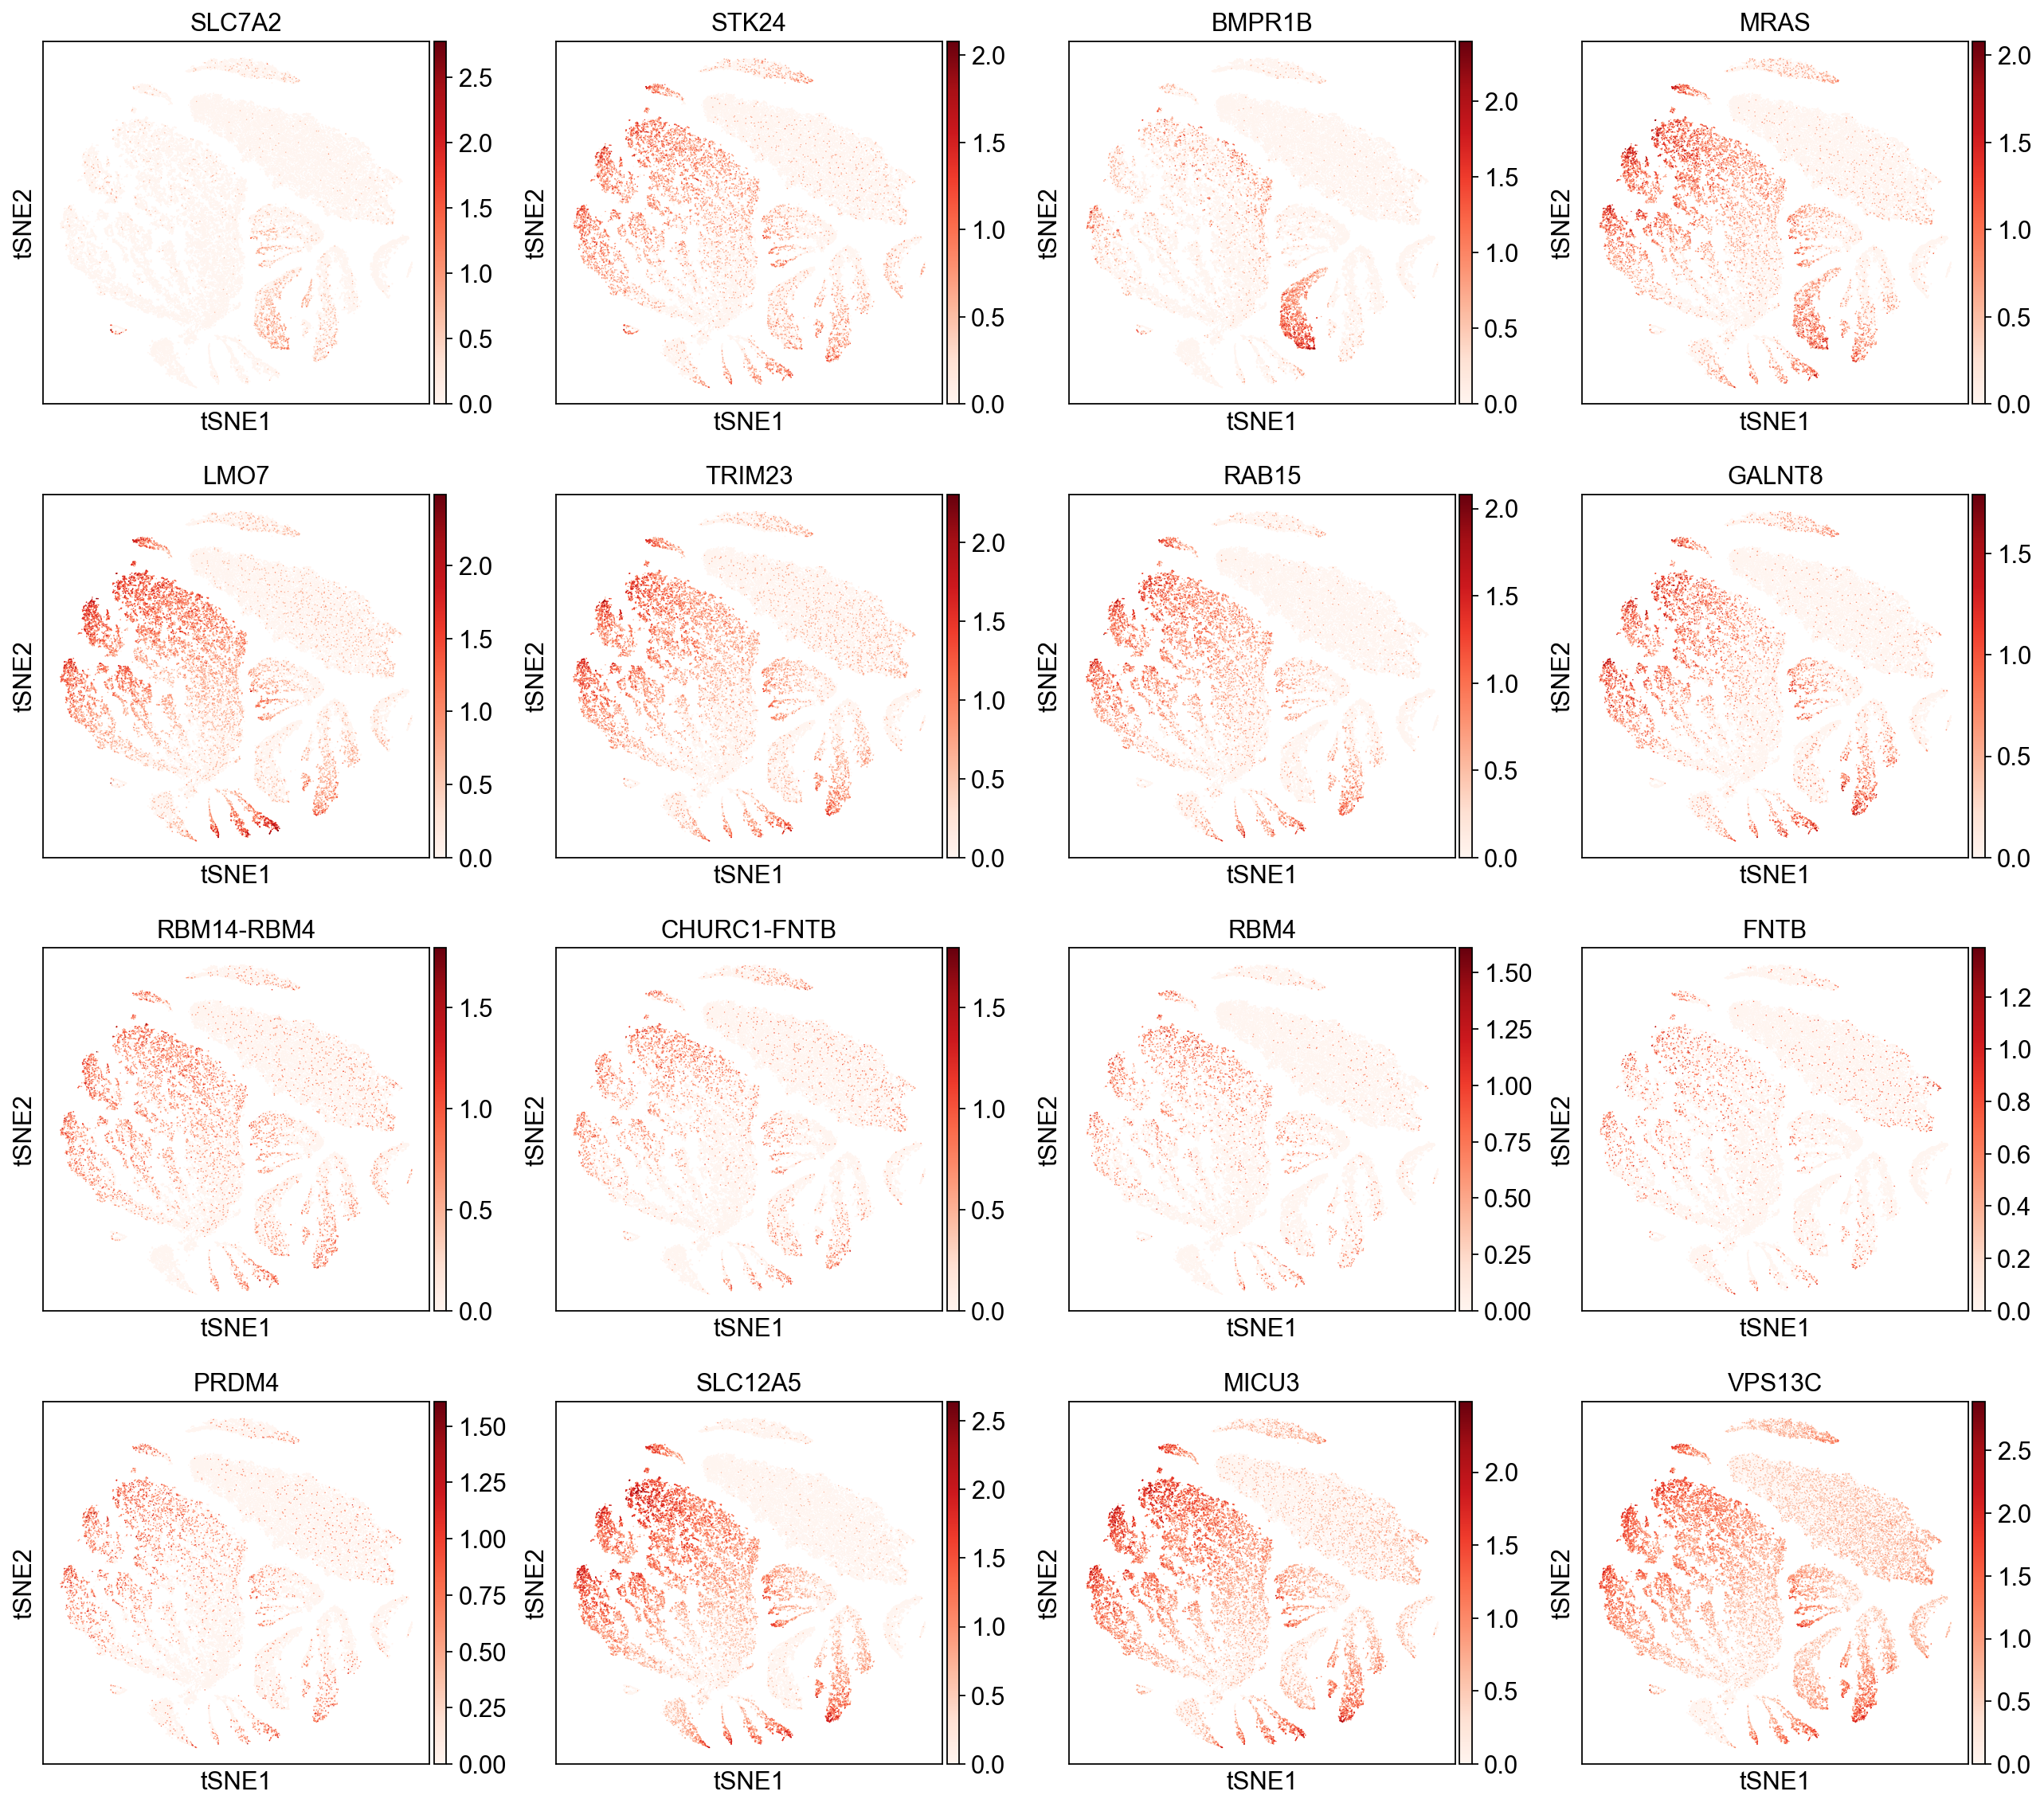

In [49]:
plt.rcParams['font.size'] = 42
plt.figure(figsize=(10, 10))
sc.pl.tsne(adata, 
           color=['SLC7A2', 'STK24', 'BMPR1B','MRAS','LMO7','TRIM23','RAB15', 'GALNT8', 'RBM14-RBM4','CHURC1-FNTB', 'RBM4','FNTB', 'PRDM4', 'SLC12A5','MICU3','VPS13C'],
           cmap='Reds',  # Change the color map to "Reds" (white to red)
           legend_fontsize=42,  # Increase the legend font size
           gene_symbols="gene_ids",
           show=False)  # Prevent the figure from showing immediately
plt.savefig('tsne_plot3.pdf', dpi=300, bbox_inches='tight')  # Save as PNG with 300 dpi

In [50]:
# Create dataframe1: cell count for each cell type and disease condition
cell_counts = bdata.obs.groupby(['cell_type', 'disease']).size().unstack(fill_value=0)
# Create dataframe2: sample count for each cell type and disease condition
sample_counts = bdata.obs.groupby(['cell_type', 'disease'])['projid'].nunique().unstack(fill_value=0)
# Save both dataframes to an Excel file
with pd.ExcelWriter('cell_and_sample_counts.xlsx') as writer:
    cell_counts.to_excel(writer, sheet_name='Cell_Counts')
    sample_counts.to_excel(writer, sheet_name='Sample_Counts')

print("DataFrames have been saved to 'cell_and_sample_counts.xlsx'.")

C:\Users\mdhdu\AppData\Local\Temp\ipykernel_10644\250746586.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = bdata.obs.groupby(['cell_type', 'disease']).size().unstack(fill_value=0)
C:\Users\mdhdu\AppData\Local\Temp\ipykernel_10644\250746586.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_counts = bdata.obs.groupby(['cell_type', 'disease'])['projid'].nunique().unstack(fill_value=0)


DataFrames have been saved to 'cell_and_sample_counts.xlsx'.
